# Week 1 — Data Stats & Exit Criteria

Pair counts, length distributions, romanizations-per-word, and the leak-free split overlap check for the Manglish transliteration project.

In [1]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

PROC_DIR = Path("../data/processed")

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]

train = load_jsonl(PROC_DIR / "train.jsonl")
val = load_jsonl(PROC_DIR / "val.jsonl")
test = load_jsonl(PROC_DIR / "test_aksharantar.jsonl")

print(f"train pairs: {len(train):,}")
print(f"val pairs:   {len(val):,}")
print(f"test pairs:  {len(test):,}")

Matplotlib is building the font cache; this may take a moment.


train pairs: 3,955,817
val pairs:   82,414
test pairs:  82,433


## Leak check: zero native-word overlap between splits

Re-derives the split.py assertion here so the notebook is a standalone proof, not just a claim.

In [2]:
train_words = {p["native"] for p in train}
val_words = {p["native"] for p in val}
test_words = {p["native"] for p in test}

assert train_words.isdisjoint(val_words)
assert train_words.isdisjoint(test_words)
assert val_words.isdisjoint(test_words)
print("PASS: no native word appears in more than one split")
print(f"unique native words: train={len(train_words):,} val={len(val_words):,} test={len(test_words):,}")

PASS: no native word appears in more than one split
unique native words: train=3,908,731 val=81,431 test=81,433


## Length distributions (romanized vs. native, character counts)

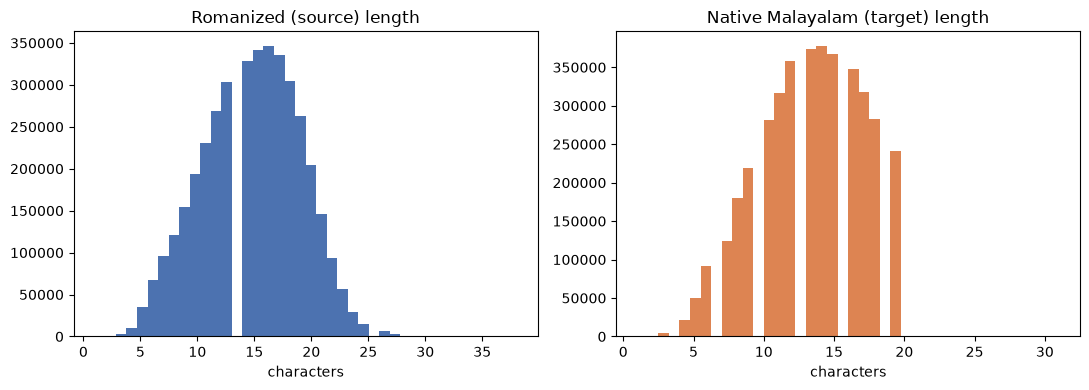

roman  len: mean=14.8 max=38
native len: mean=13.2 max=31


In [3]:
roman_lens = [len(p["roman"]) for p in train]
native_lens = [len(p["native"]) for p in train]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(roman_lens, bins=40, color="#4C72B0")
axes[0].set_title("Romanized (source) length")
axes[0].set_xlabel("characters")
axes[1].hist(native_lens, bins=40, color="#DD8452")
axes[1].set_title("Native Malayalam (target) length")
axes[1].set_xlabel("characters")
plt.tight_layout()
plt.savefig("figures_length_hist.png", dpi=120)
plt.show()

print(f"roman  len: mean={sum(roman_lens)/len(roman_lens):.1f} max={max(roman_lens)}")
print(f"native len: mean={sum(native_lens)/len(native_lens):.1f} max={max(native_lens)}")

## Romanizations per native word

This is the ambiguity signal the whole project rests on — one Malayalam word often has several plausible Latin spellings ("ente", "ende", "enthe"). More of these = more genuinely hard, non-arbitrary cases for the model.

In [4]:
romanizations_per_word = defaultdict(set)
for p in train:
    romanizations_per_word[p["native"]].add(p["roman"])

counts = Counter(len(v) for v in romanizations_per_word.values())
for k in sorted(counts)[:10]:
    print(f"{k} romanization(s): {counts[k]:,} native words")

multi = {w: sorted(rs) for w, rs in romanizations_per_word.items() if len(rs) >= 4}
print(f"\n{len(multi):,} words have 4+ distinct romanizations. Example:")
example_word = next(iter(multi))
print(example_word, "->", multi[example_word][:8])

1 romanization(s): 3,879,773 native words
2 romanization(s): 19,575 native words
3 romanization(s): 6,033 native words
4 romanization(s): 1,936 native words
5 romanization(s): 509 native words
6 romanization(s): 215 native words
7 romanization(s): 139 native words
8 romanization(s): 114 native words
9 romanization(s): 111 native words
10 romanization(s): 74 native words



3,350 words have 4+ distinct romanizations. Example:
ഉത്രാളിക്കാവ് -> ['utharalikkavu', 'uthraalikkaavu', 'uthraalikkavu', 'uthralikkavu']
